Ejercicio4

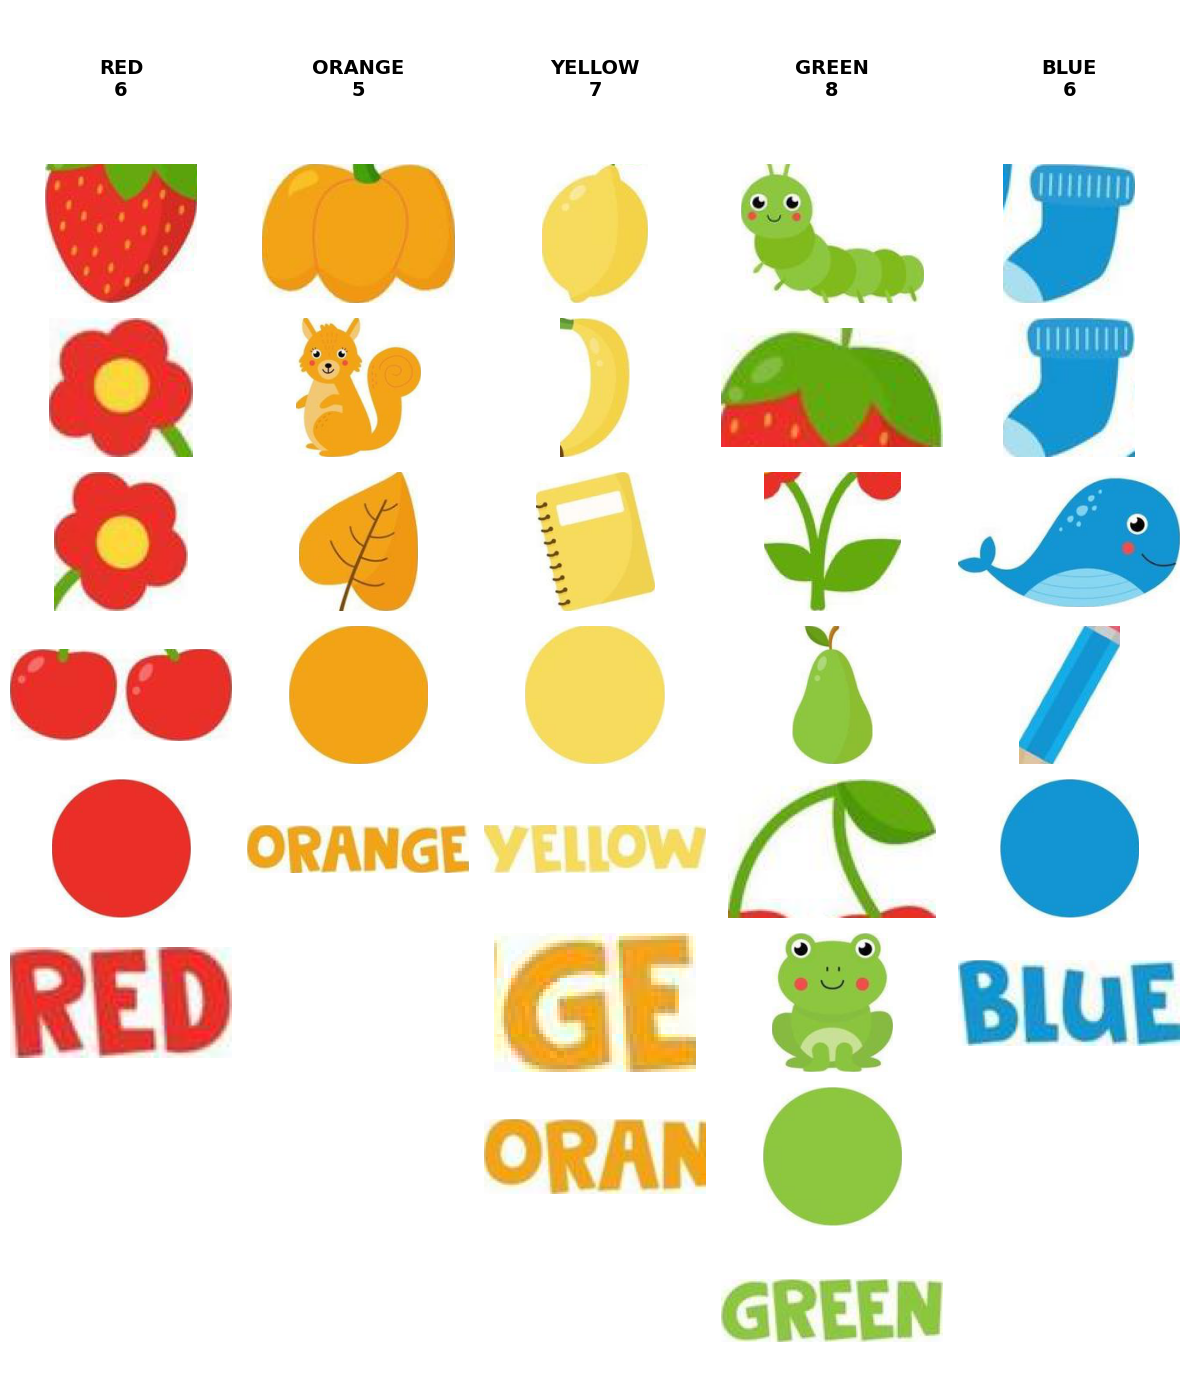

Total de objetos: 32


In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Cargar imagen
img_bgr = cv2.imread('colores.jpg')
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Rangos HSV y colores
color_ranges = {
    'RED': [
        (np.array([0, 80, 80]), np.array([10, 255, 255])),
        (np.array([160, 80, 80]), np.array([180, 255, 255]))
    ],
    'ORANGE': [(np.array([10, 120, 100]), np.array([22, 255, 255]))],
    'YELLOW': [(np.array([22, 80, 150]), np.array([35, 255, 255]))],
    'GREEN': [(np.array([35, 60, 60]), np.array([90, 255, 255]))],
    'BLUE': [(np.array([90, 60, 60]), np.array([140, 255, 255]))]
}

# Contar objetos
results = {}
for color_name, ranges in color_ranges.items():
    mask = np.zeros(img_hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask |= cv2.inRange(img_hsv, lower, upper)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) >= 800]
    results[color_name] = (len(contours), contours, mask)

# Visualizar en cuadrícula 5 columnas
colors_list = list(results.keys())
max_objects = max(count for count, _, _ in results.values())
fig, axes = plt.subplots(max_objects + 1, 5, figsize=(12, 14))

for col, color_name in enumerate(colors_list):
    count, contours, mask = results[color_name]
    
    # Primera fila: título del color
    axes[0, col].text(0.5, 0.5, f'{color_name}\n{count}', 
                      fontsize=14, fontweight='bold', ha='center', va='center')
    axes[0, col].axis('off')
    
    # Objetos individuales
    for row, contour in enumerate(contours, start=1):
        x, y, w, h = cv2.boundingRect(contour)
        obj = img_rgb[y:y+h, x:x+w].copy()
        axes[row, col].imshow(obj)
        axes[row, col].axis('off')
    
    # Limpiar filas vacías
    for row in range(len(contours) + 1, max_objects + 1):
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('resultado_colores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total de objetos: {sum(c for c, _, _ in results.values())}')